In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

## Data Cleaning for Chess Games Dataset

In [5]:

# Load the chess games dataset
df_chess = pd.read_csv("games.csv")

print("First 5 rows of the dataset:")
display(df_chess.head())

print("\nShape of the dataset:")
print(df_chess.shape)

print("\nInformation about the dataset (data types and non-null counts):")
df_chess.info()

First 5 rows of the dataset:


,id,rated,created_at,last_move_at,turns,victory_status,winner,increment_code,white_id,white_rating,black_id,black_rating,moves,opening_eco,opening_name,opening_ply
0,TZJHLljE,False,1.504210e+12,1.504210e+12,13,outoftime,white,15+2,bourgris,1500,a-00,1191,d4 d5 c4 c6 cxd5 e6 dxe6 fxe6 Nf3 Bb4+ Nc3 Ba5...,D10,Slav Defense: Exchange Variation,5
1,l1NXvwaE,True,1.504130e+12,1.504130e+12,16,resign,black,5+10,a-00,1322,skinnerua,1261,d4 Nc6 e4 e5 f4 f6 dxe5 fxe5 fxe5 Nxe5 Qd4 Nc6...,B00,Nimzowitsch Defense: Kennedy Variation,4
2,mIICvQHh,True,1.504130e+12,1.504130e+12,61,mate,white,5+10,ischia,1496,a-00,1500,e4 e5 d3 d6 Be3 c6 Be2 b5 Nd2 a5 a4 c5 axb5 Nc...,C20,King's Pawn Game: Leonardis Variation,3
3,kWKvrqYL,True,1.504110e+12,1.504110e+12,61,mate,white,20+0,daniamurashov,1439,adivanov2009,1454,d4 d5 Nf3 Bf5 Nc3 Nf6 Bf4 Ng4 e3 Nc6 Be2 Qd7 O...,D02,Queen's Pawn Game: Zukertort Variation,3
4,9tXo1AUZ,True,1.504030e+12,1.504030e+12,95,mate,white,30+3,nik221107,1523,adivanov2009,1469,e4 e5 Nf3 d6 d4 Nc6 d5 Nb4 a3 Na6 Nc3 Be7 b4 N...,C41,Philidor Defense,5



Shape of the dataset:
(20058, 16)

Information about the dataset (data types and non-null counts):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20058 entries, 0 to 20057
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              20058 non-null  object 
 1   rated           20058 non-null  bool   
 2   created_at      20058 non-null  float64
 3   last_move_at    20058 non-null  float64
 4   turns           20058 non-null  int64  
 5   victory_status  20058 non-null  object 
 6   winner          20058 non-null  object 
 7   increment_code  20058 non-null  object 
 8   white_id        20058 non-null  object 
 9   white_rating    20058 non-null  int64  
 10  black_id        20058 non-null  object 
 11  black_rating    20058 non-null  int64  
 12  moves           20058 non-null  object 
 13  opening_eco     20058 non-null  object 
 14  opening_name    20058 non-null  object 
 15  opening_ply     20058

In [6]:
# Check for missing values
print("\nMissing Values before handling:")
print(df_chess.isnull().sum())


Missing Values before handling:
id                0
rated             0
created_at        0
last_move_at      0
turns             0
victory_status    0
winner            0
increment_code    0
white_id          0
white_rating      0
black_id          0
black_rating      0
moves             0
opening_eco       0
opening_name      0
opening_ply       0
dtype: int64


### Handle Missing Values

I will fill numerical missing values with the median of their respective columns. For categorical columns like `opening_name`, I will fill them with the mode.

In [7]:
# Fill numerical missing values with the median
numeric_cols_chess = df_chess.select_dtypes(include=np.number).columns
df_chess[numeric_cols_chess] = df_chess[numeric_cols_chess].fillna(df_chess[numeric_cols_chess].median())

# Fill categorical missing values with the mode (e.g., 'opening_name')
for col in df_chess.select_dtypes(include='object').columns:
    if df_chess[col].isnull().any():
        df_chess[col] = df_chess[col].fillna(df_chess[col].mode()[0])

print("Missing Values after handling:")
print(df_chess.isnull().sum())

Missing Values after handling:
id                0
rated             0
created_at        0
last_move_at      0
turns             0
victory_status    0
winner            0
increment_code    0
white_id          0
white_rating      0
black_id          0
black_rating      0
moves             0
opening_eco       0
opening_name      0
opening_ply       0
dtype: int64


### Handle Duplicate Rows

In [8]:
print("Duplicate Rows before removal:", df_chess.duplicated().sum())
df_chess.drop_duplicates(inplace=True)
print("After Removal, shape of dataset:", df_chess.shape)

Duplicate Rows before removal: 429
After Removal, shape of dataset: (19629, 16)


### Handle Outliers (for `turns` column)

Similar to the `AQI` column in the previous example, I'll identify and visualize outliers for the `turns` column using the IQR method. Outliers will not be removed in this step, but identified.

Outliers in 'turns' column (first 5 rows if any):

           id  rated    created_at  last_move_at  turns victory_status winner  \
148  JbLparSt   True  1.503060e+12  1.503060e+12    156           mate  black   
176  fPPfEuu5  False  1.503090e+12  1.503090e+12    144      outoftime   draw   
180  46AuHfcq   True  1.501980e+12  1.501980e+12    158           mate  black   
190  OmwDxZpJ   True  1.501090e+12  1.501090e+12    178           mate  black   
213  mJ9VpdxV   True  1.503660e+12  1.503670e+12    159           mate  white   

    increment_code       white_id  white_rating          black_id  \
148          15+15         sassou          1226  vladimir_shindin   
176           10+0       isachess          1866       teguhmaster   
180            6+6           humb          1835          isachess   
190           16+0  sergeylobanov          1843          isachess   
213           15+1        taranga          1280            moon50   

     black_rating                              

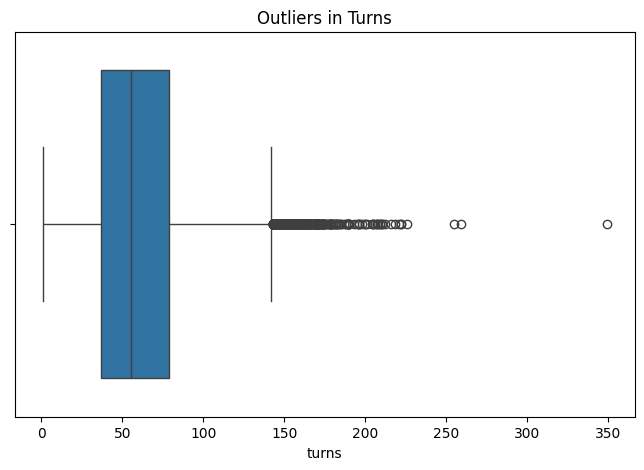

In [11]:
Q1_turns = df_chess["turns"].quantile(0.25)
Q3_turns = df_chess["turns"].quantile(0.75)

IQR_turns = Q3_turns - Q1_turns

lower_turns = Q1_turns - 1.5 * IQR_turns
upper_turns = Q3_turns + 1.5 * IQR_turns

outliers_turns = df_chess[(df_chess["turns"] < lower_turns) | (df_chess["turns"] > upper_turns)]

print("Outliers in 'turns' column (first 5 rows if any):\n")
print(outliers_turns.head())

plt.figure(figsize=(8,5))
sns.boxplot(x=df_chess["turns"])
plt.title("Outliers in Turns")
plt.show()

### Scale Numerical Features (e.g., `white_rating`)

I will use `MinMaxScaler` to scale the `white_rating` column to a range between 0 and 1.

In [13]:
from sklearn.preprocessing import MinMaxScaler

scaler_chess = MinMaxScaler()
df_chess[["white_rating"]] = scaler_chess.fit_transform(df_chess[["white_rating"]])

print("Scaled 'white_rating' (first 5 rows):\n")
print(df_chess[["white_rating"]].head())

Scaled 'white_rating' (first 5 rows):

   white_rating
0      0.373695
1      0.280793
2      0.371608
3      0.341858
4      0.385699


### Encode Categorical Features

I will use `LabelEncoder` for the `victory_status` column and `pd.get_dummies` for the `rated` column (converting boolean to numerical one-hot encoding).

In [15]:
from sklearn.preprocessing import LabelEncoder

# Label Encode 'victory_status'
encoder_chess = LabelEncoder()
df_chess["victory_status_encoded"] = encoder_chess.fit_transform(df_chess["victory_status"])

print("Encoded 'victory_status_encoded' (first 5 rows):\n")
print(df_chess[["victory_status", "victory_status_encoded"]].head())

# One-Hot Encode 'rated' column
rated_dummies = pd.get_dummies(df_chess["rated"], prefix='rated')
df_chess = pd.concat([df_chess, rated_dummies], axis=1)
df_chess.drop("rated", axis=1, inplace=True) # Drop original 'rated' column

print("\nOne-Hot Encoded 'rated' column (first 5 rows):\n")
print(df_chess[['rated_False', 'rated_True']].head())

Encoded 'victory_status_encoded' (first 5 rows):

  victory_status  victory_status_encoded
0      outoftime                       2
1         resign                       3
2           mate                       1
3           mate                       1
4           mate                       1

One-Hot Encoded 'rated' column (first 5 rows):

   rated_False  rated_True
0         True       False
1        False        True
2        False        True
3        False        True
4        False        True


### Save Cleaned Dataset

In [16]:
# Drop original 'victory_status' column as it's now encoded
df_chess.drop("victory_status", axis=1, inplace=True)

# Save the cleaned dataset
df_chess.to_csv("cleaned_games.csv", index=False)
print("Cleaned chess games dataset saved successfully as 'cleaned_games.csv'.")

Cleaned chess games dataset saved successfully as 'cleaned_games.csv'.
